# 초기 관찰 구간과 knee 후보 — N07–N08

두 번째 묶음. 초기 특징의 구간 민감도와 후기 열화 구조를 구분한다. knee는 명시된 탐색 기준의 후보이며 실제 물리적 전환점으로 확정하지 않는다.

In [1]:
from pathlib import Path
import sys
cwd=Path.cwd().resolve()
PROJECT_ROOT=next(p for p in [cwd,*cwd.parents] if (p/'src/window_knee_eda.py').is_file())
if str(PROJECT_ROOT) not in sys.path:sys.path.insert(0,str(PROJECT_ROOT))
import matplotlib.pyplot as plt
from IPython.display import display
from src import window_knee_eda as wk
OUTPUT_DIR=PROJECT_ROOT/'outputs/figures/window_knee_exploration'
features,audit,correlations,selected,fits,curves,review_samples=wk.build_window_knee_data(PROJECT_ROOT/'data/raw')
wk.save_tables(OUTPUT_DIR,features,audit,correlations,fits,curves,review_samples)
print('Endpoint feature rows:',len(features),'detailed alignment checks:',len(audit))
print('Knee configurations:',len(fits),'selected cells:',len(selected))
display(correlations[correlations.population.eq('common_cells')])

Matplotlib is building the font cache; this may take a moment.


Endpoint feature rows: 417 detailed alignment checks: 556
Knee configurations: 120 selected cells: 10


,batch,feature,end_cycle,population,method,n,correlation
0,batch1,deltaQ_var,50,common_cells,pearson,46,-0.756171
1,batch1,deltaQ_var,50,common_cells,spearman,46,-0.791908
6,batch1,deltaQ_var,75,common_cells,pearson,46,-0.837915
7,batch1,deltaQ_var,75,common_cells,spearman,46,-0.865302
12,batch1,deltaQ_var,100,common_cells,pearson,46,-0.837826
...,...,...,...,...,...,...,...
199,batch3,QD_slope_masked,50,common_cells,spearman,44,0.107548
204,batch3,QD_slope_masked,75,common_cells,pearson,44,0.347544
205,batch3,QD_slope_masked,75,common_cells,spearman,44,0.146029
210,batch3,QD_slope_masked,100,common_cells,pearson,44,0.360500


## N07 — 초기 구간 비교

ΔQ는 Q50−Q10, Q75−Q10, Q100−Q10이다. 기울기는 10–50, 10–75, 10–100에서 급등 유지·마스킹 조건을 비교한다. 수명 상관은 구간에 공통으로 유효한 셀 기준이며, 수명 누락도 포함한 전후 변화는 세 번째 그림에 표시한다.

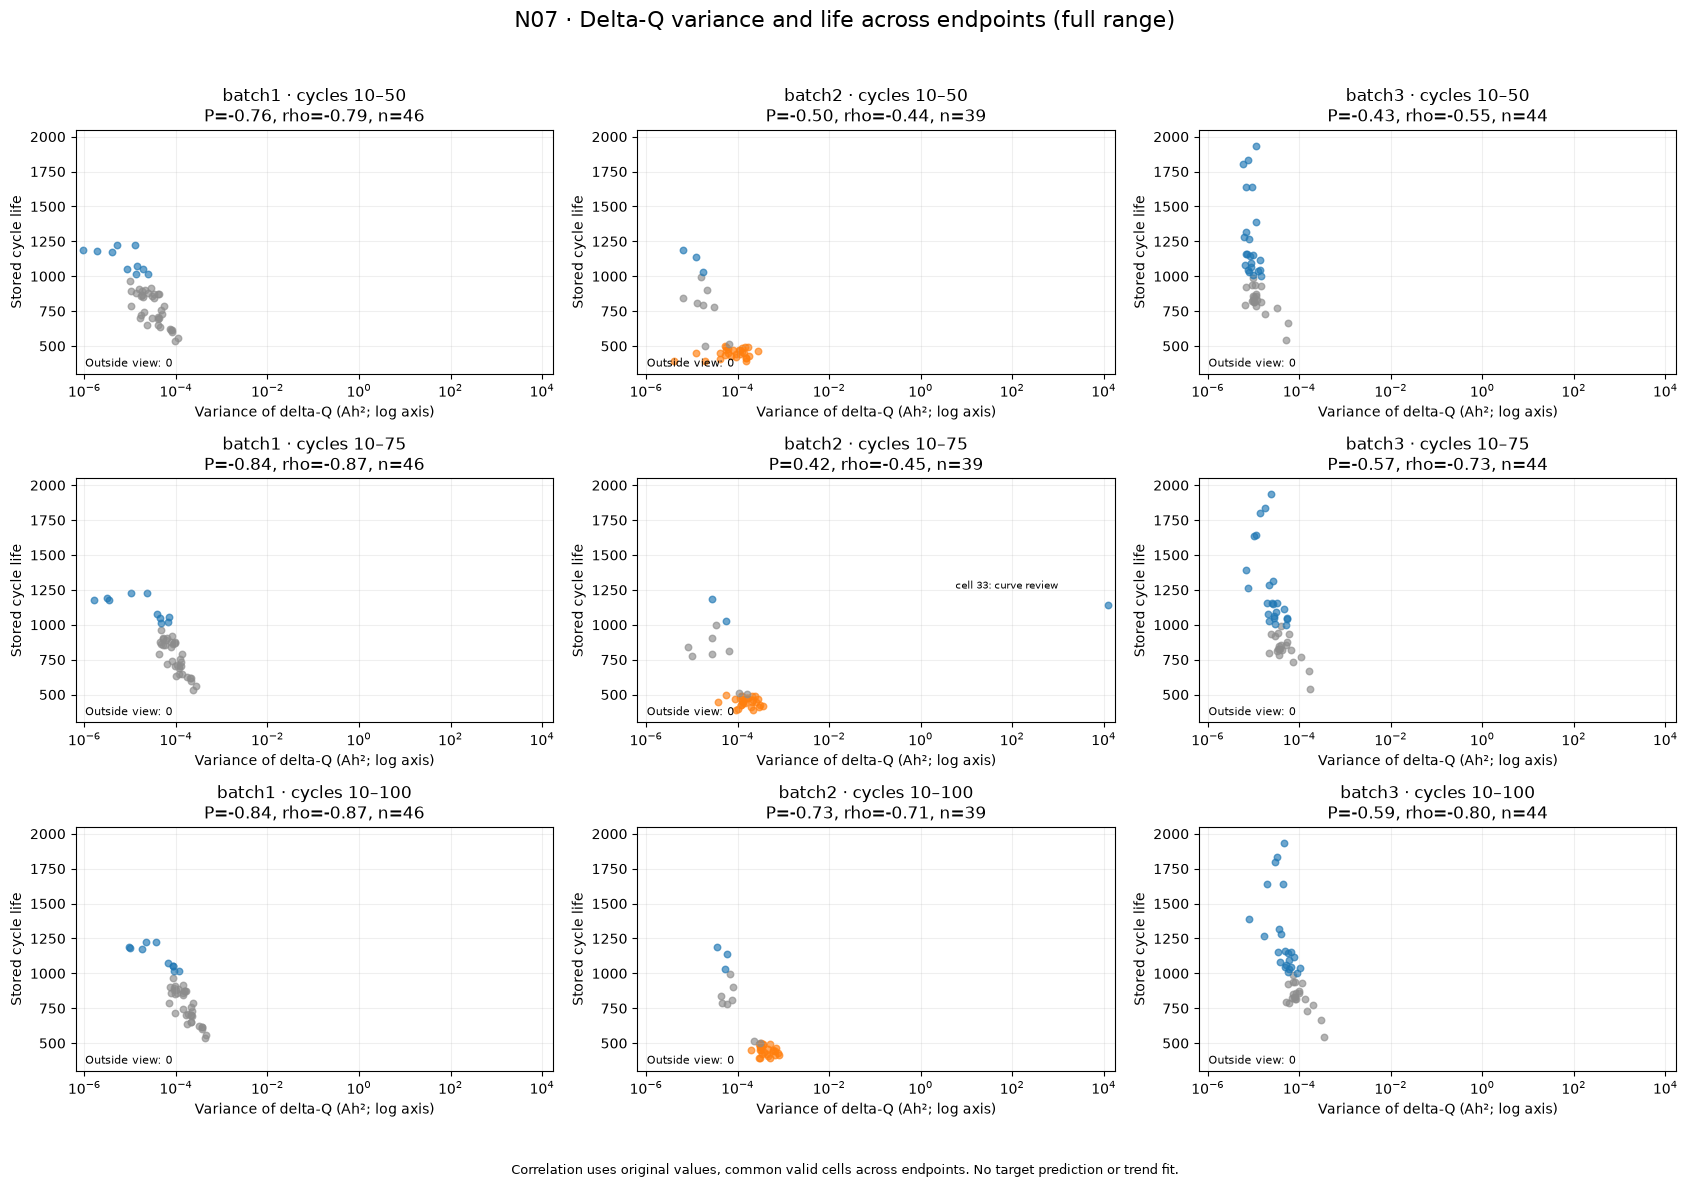

In [2]:
fig=wk.figure_window_relationship(features,correlations,'delta')
fig.savefig(OUTPUT_DIR/'N07_delta_variance_endpoints.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

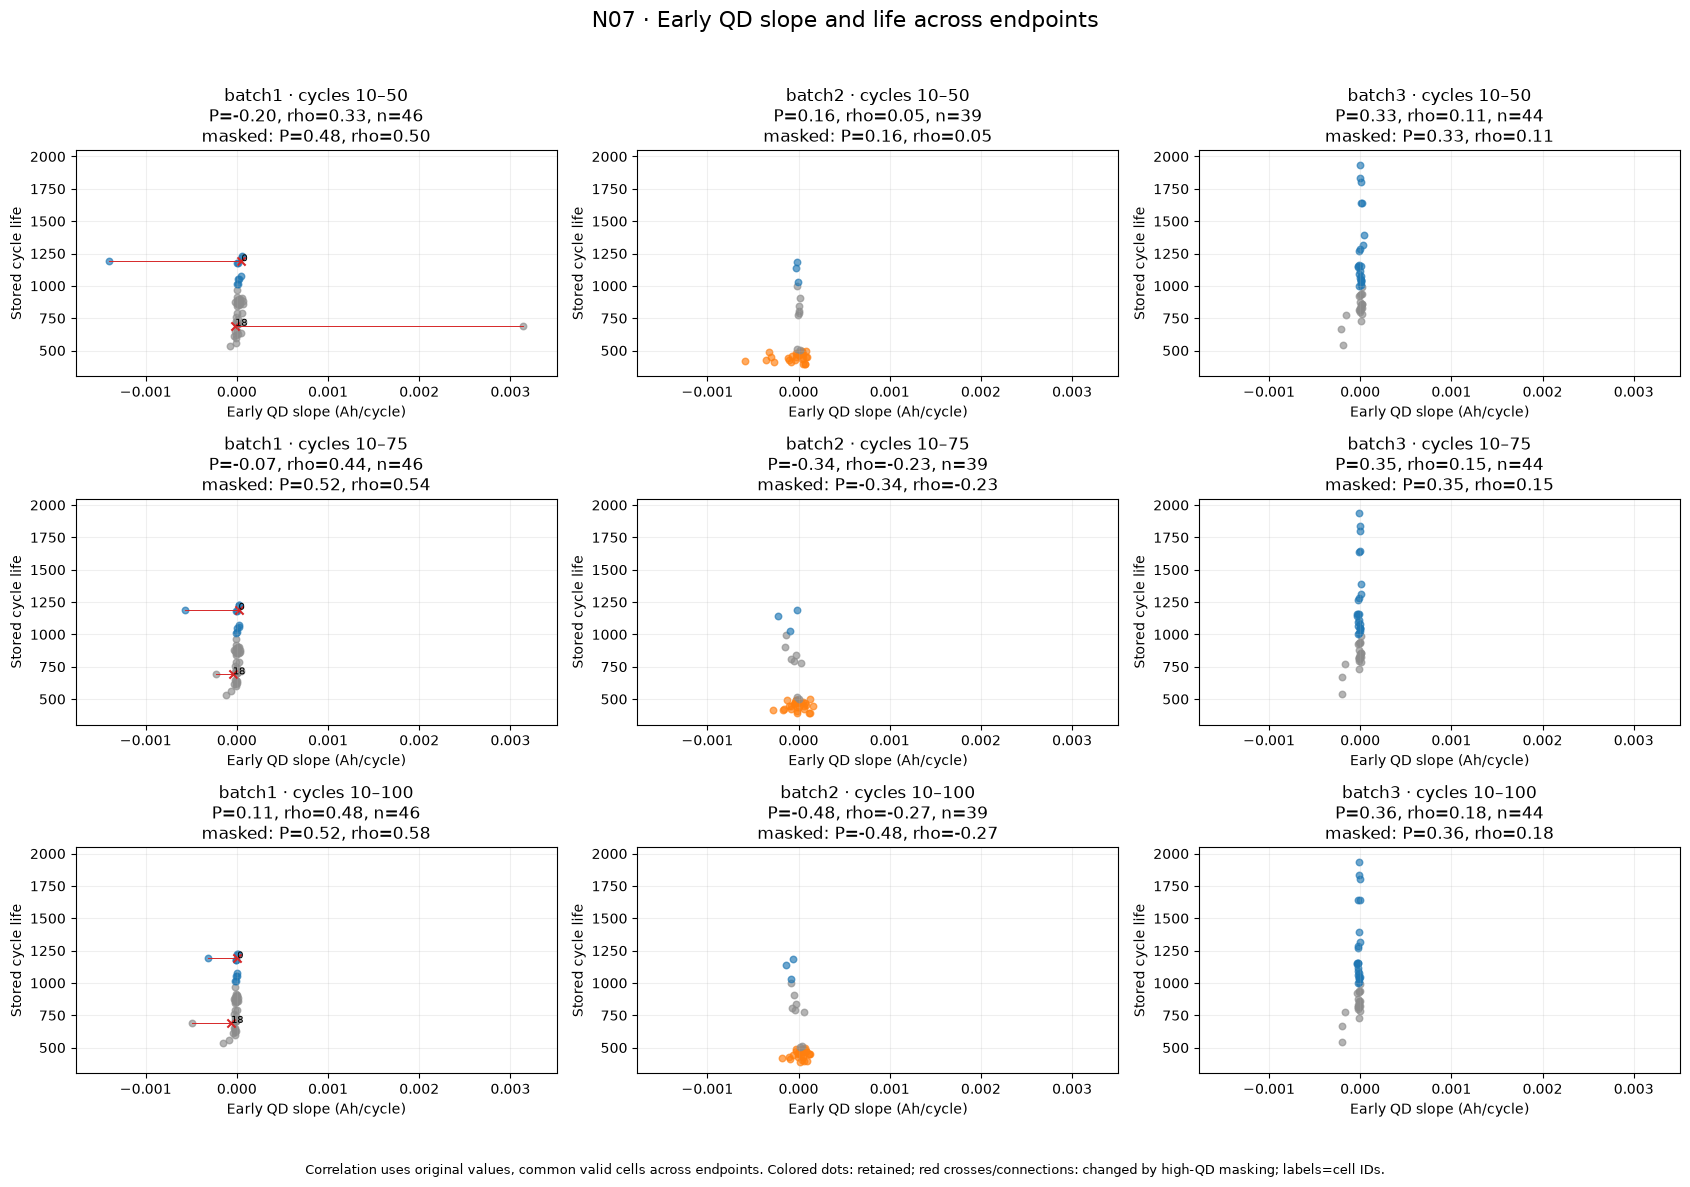

In [3]:
fig=wk.figure_window_relationship(features,correlations,'slope')
fig.savefig(OUTPUT_DIR/'N07_qd_slope_endpoints.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

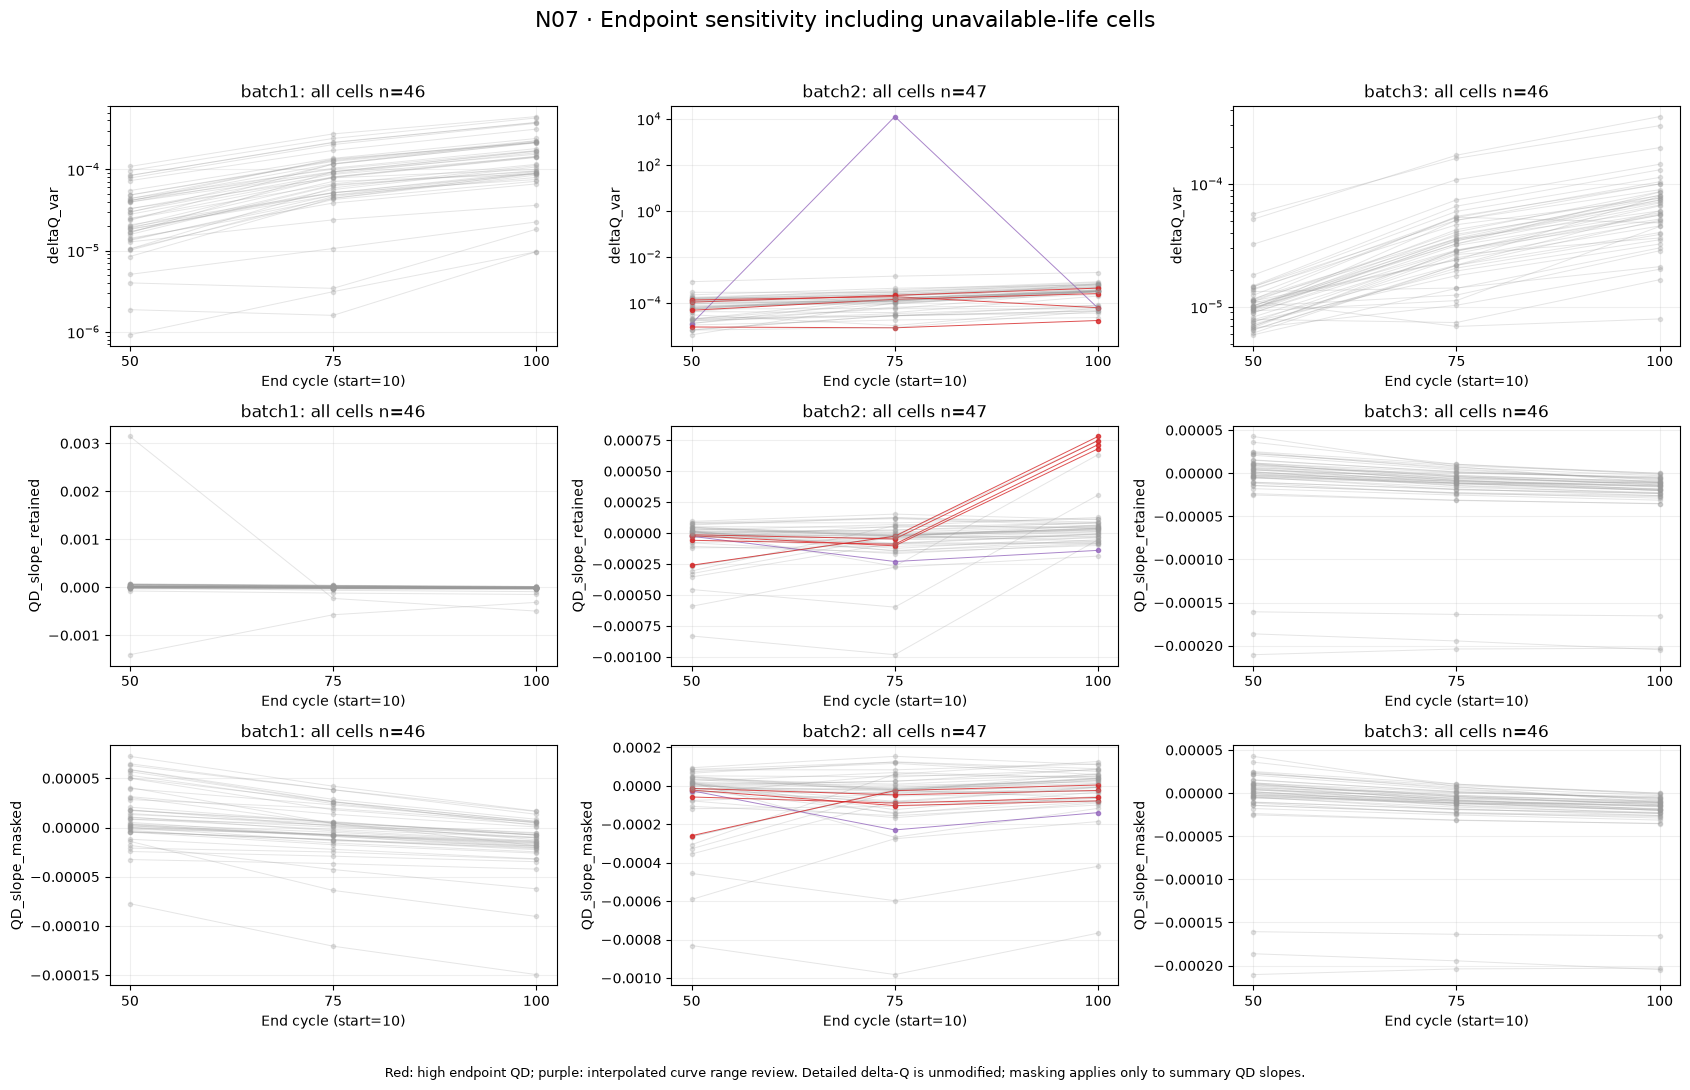

,batch,cell_id,end_cycle,cycle_life,life_group,charging_policy,deltaQ_var,deltaQ_min,delta_curve_review,delta_status,endpoint_high_QD,n_QD_retained,QD_slope_retained,n_QD_masked,QD_slope_masked
251,batch2,37,100,NaN,unavailable life,3.6C(80%)-3.6C(SLOWCYCLE,0.000017,-0.028682,False,accepted,True,91,0.000780,90,0.000004
254,batch2,38,100,NaN,unavailable life,4.8C(80%)-4.8C(SLOWCYCLE,0.000061,-0.036150,False,accepted,True,91,0.000714,90,-0.000061
257,batch2,39,100,NaN,unavailable life,3.6C(9%)-5C(SLOWCYCLE,0.000434,-0.060952,False,accepted,True,91,0.000681,90,-0.000079
260,batch2,40,100,NaN,unavailable life,5.2C(58%)-4C(SLOWCYCLE,0.000251,-0.048163,False,accepted,True,91,0.000748,90,-0.000024


In [4]:
fig=wk.figure_all_cell_windows(features)
fig.savefig(OUTPUT_DIR/'N07_all_cell_endpoint_changes.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)
display(features[features.endpoint_high_QD])

### 전압별 보간 곡선의 검토

Qdlin 범위가 −0.05 아래 또는 상세 최대 Qd의 1.2배 위이면 검토 플래그를 붙인다. 요약 QD 급등 플래그와 다르며 원본 특징을 유지한다. 확대 그림은 값을 숨길 수 있으므로 전체 그림과 같이 본다. 원래 상관은 모든 유효 셀로 계산하고, 검토 대상 제외 수치는 민감도 조건으로 별도 저장한다.

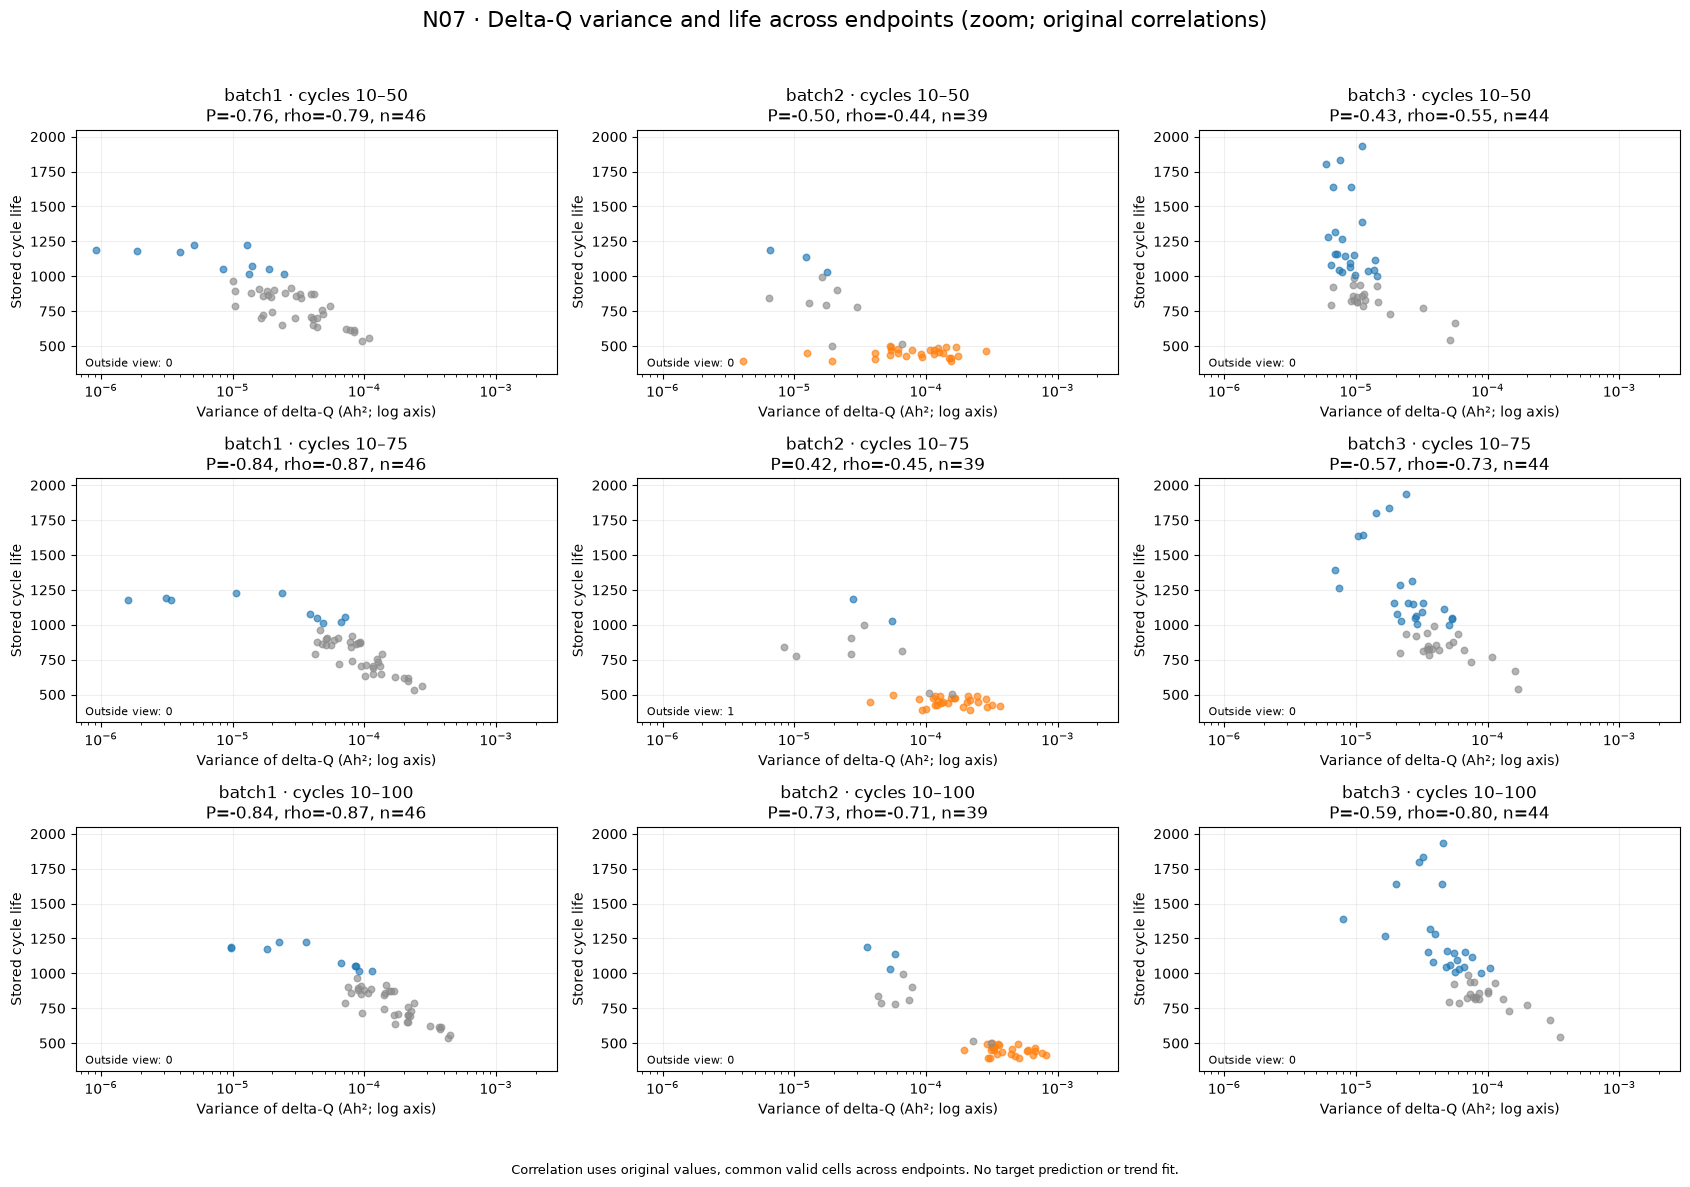

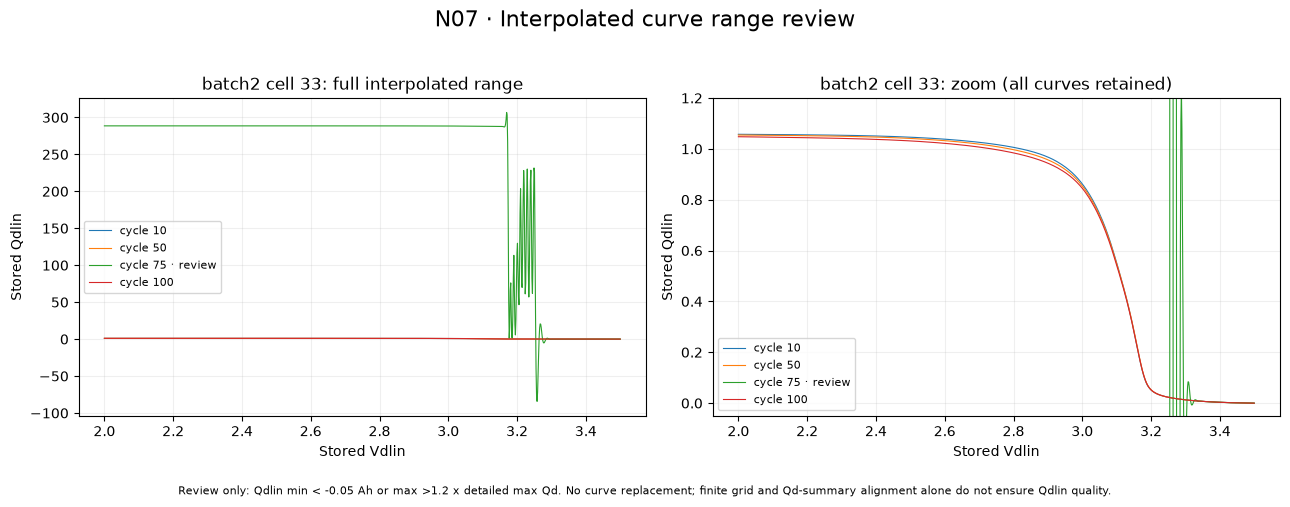

,batch,cell_id,cycle,storage_index,summary_QD,detail_Qd_max,alignment_passed,grid_points,Qdlin_min,Qdlin_max,Qdlin_range_review
318,batch2,33,75,74,0.925753,0.925753,True,1000,-84.265228,306.735963,True


,batch,feature,end_cycle,population,method,n,correlation
4,batch1,deltaQ_var,50,curve_review_excluded,pearson,46,-0.756171
5,batch1,deltaQ_var,50,curve_review_excluded,spearman,46,-0.791908
10,batch1,deltaQ_var,75,curve_review_excluded,pearson,46,-0.837915
11,batch1,deltaQ_var,75,curve_review_excluded,spearman,46,-0.865302
16,batch1,deltaQ_var,100,curve_review_excluded,pearson,46,-0.837826
17,batch1,deltaQ_var,100,curve_review_excluded,spearman,46,-0.871161
76,batch2,deltaQ_var,50,curve_review_excluded,pearson,39,-0.504000
77,batch2,deltaQ_var,50,curve_review_excluded,spearman,39,-0.437291
82,batch2,deltaQ_var,75,curve_review_excluded,pearson,38,-0.611793
83,batch2,deltaQ_var,75,curve_review_excluded,spearman,38,-0.559422


In [5]:
fig=wk.figure_window_relationship(features,correlations,'delta',zoom=True)
fig.savefig(OUTPUT_DIR/'N07_delta_variance_endpoints_zoom.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)
if not review_samples.empty:
    fig=wk.figure_curve_review(review_samples)
    fig.savefig(OUTPUT_DIR/'N07_interpolated_curve_review.png',dpi=130,bbox_inches='tight')
    plt.show()
    plt.close(fig)
display(audit[audit.Qdlin_range_review])
display(correlations[correlations.population.eq('curve_review_excluded') & correlations.feature.eq('deltaQ_var')])

## N08 — 열화 속도와 knee 후보

선택 셀은 기존 수명 그룹 대표 7개와 급등 사례 3개다. cycle≥10을 사용하고 수명이 알려졌으면 그 회차까지 자른다. 이는 전체 기록을 사용하는 사후 탐색이며 초기 예측 특징이 아니다.

기본 표시는 QD>1.32 마스킹·중앙 이동 중앙값 11·후보 양쪽 최소 길이 75다. 연속 분할 직선의 SSE가 최소인 위치를 매 5개 cycle 위치에서 탐색한다. 양쪽 최소 관측 20개, SSE 개선≥20%, 이후 음의 기울기, 기울기 감소>1e−5 Ah/cycle, 기존 감소 기울기의 1.5배 이상이면 탐색 기준 통과로 표시한다. 평활 1·11·31, 최소 길이 30·75, 급등 유지·마스킹의 12조건을 비교한다.

결측 또는 없는 회차를 이어 붙이지 않는다. 평활은 완전한 창에서만 계산하고, 적합은 가장 긴 유효 연속 구간에 제한한다. 평활은 미래 지점도 쓰는 사후 계산이다. 통과는 실제 knee 검증을 뜻하지 않는다.

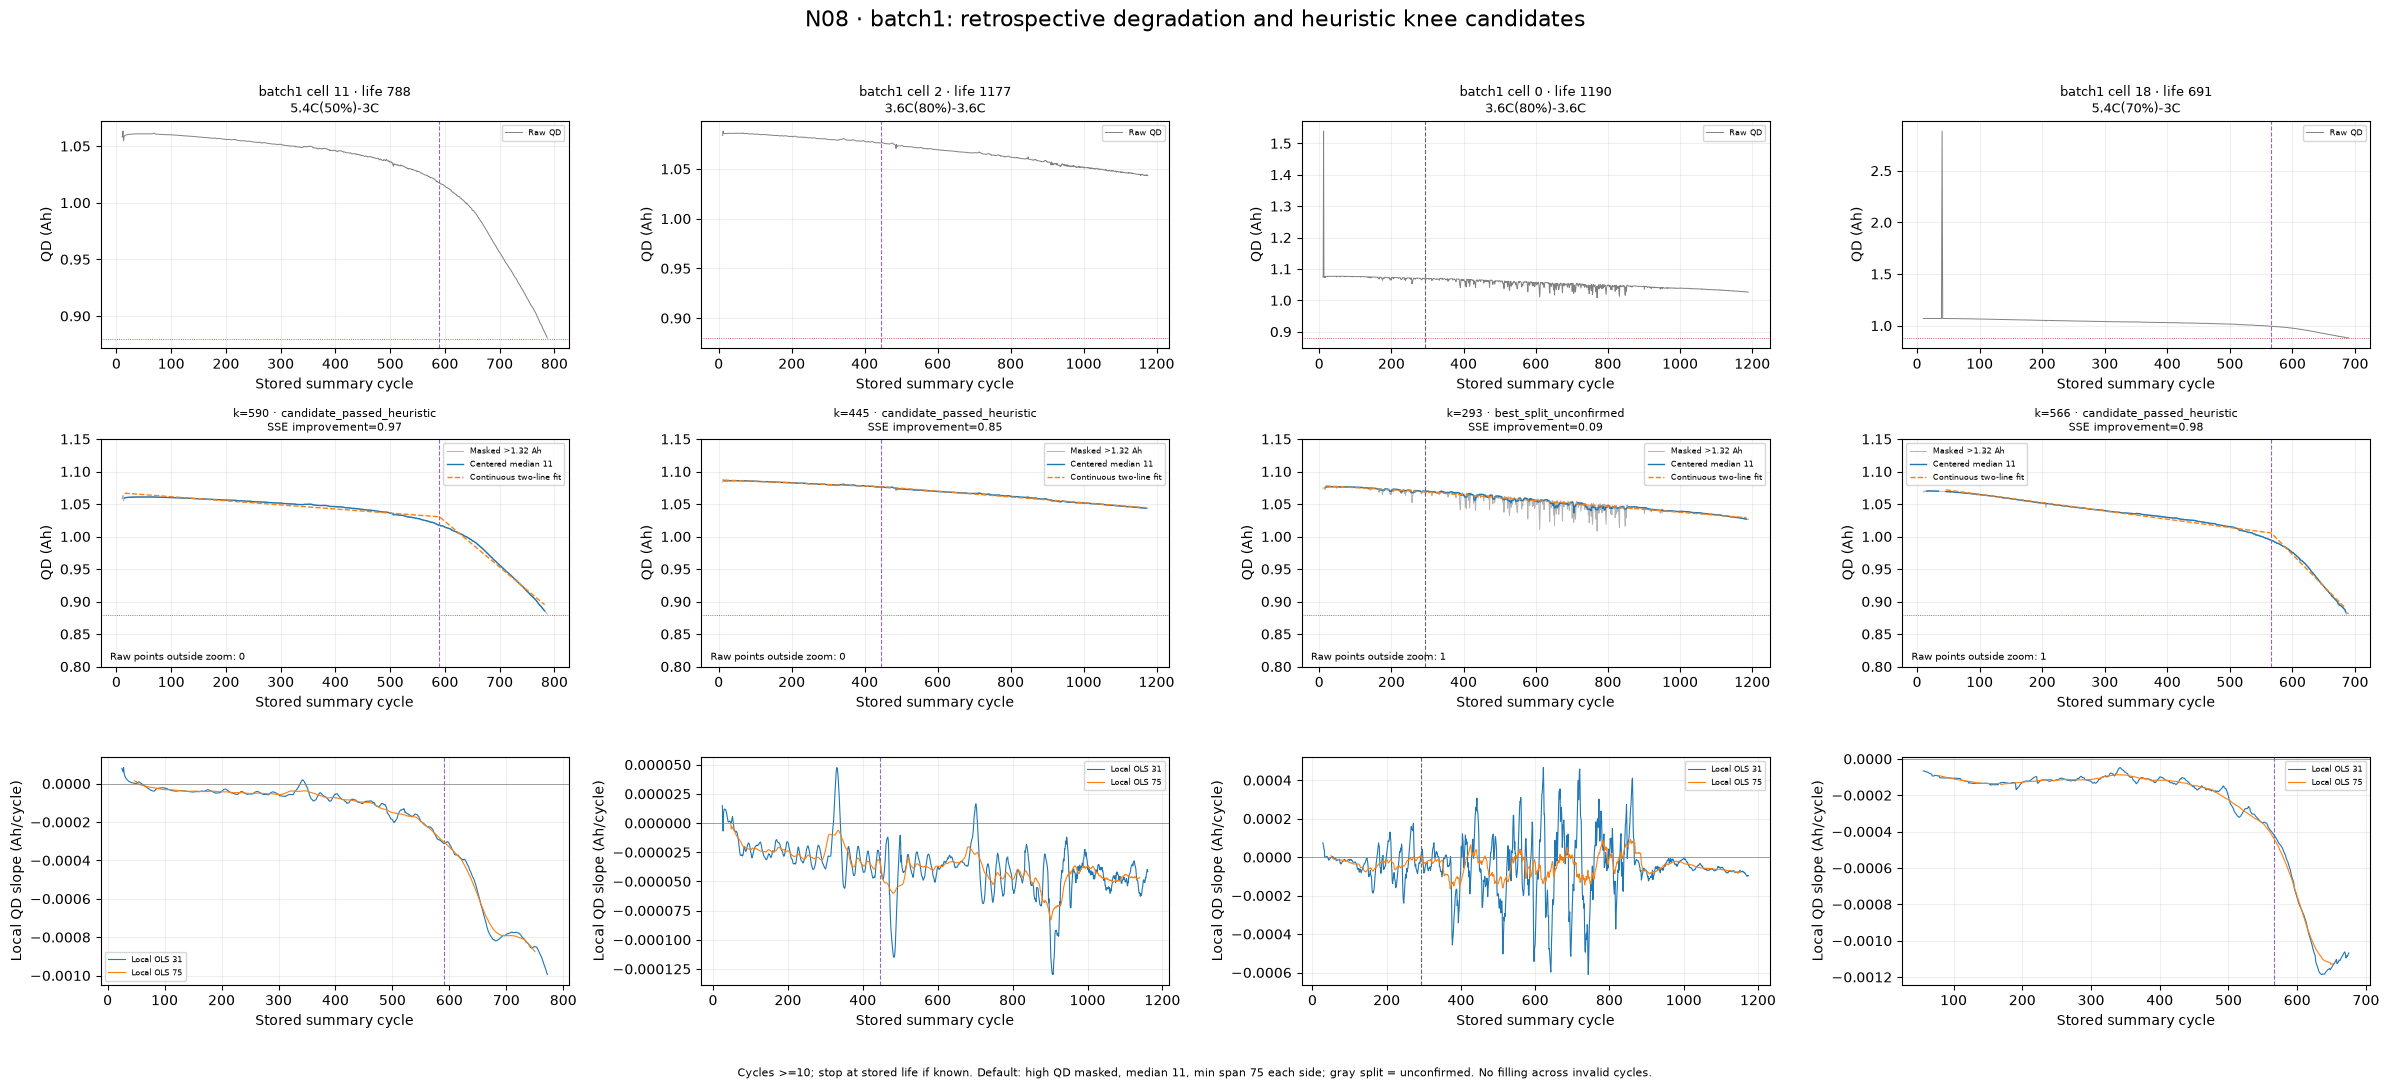

In [6]:
fig=wk.figure_knee_curves(selected,fits,'batch1')
fig.savefig(OUTPUT_DIR/'N08_batch1_degradation_knee.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

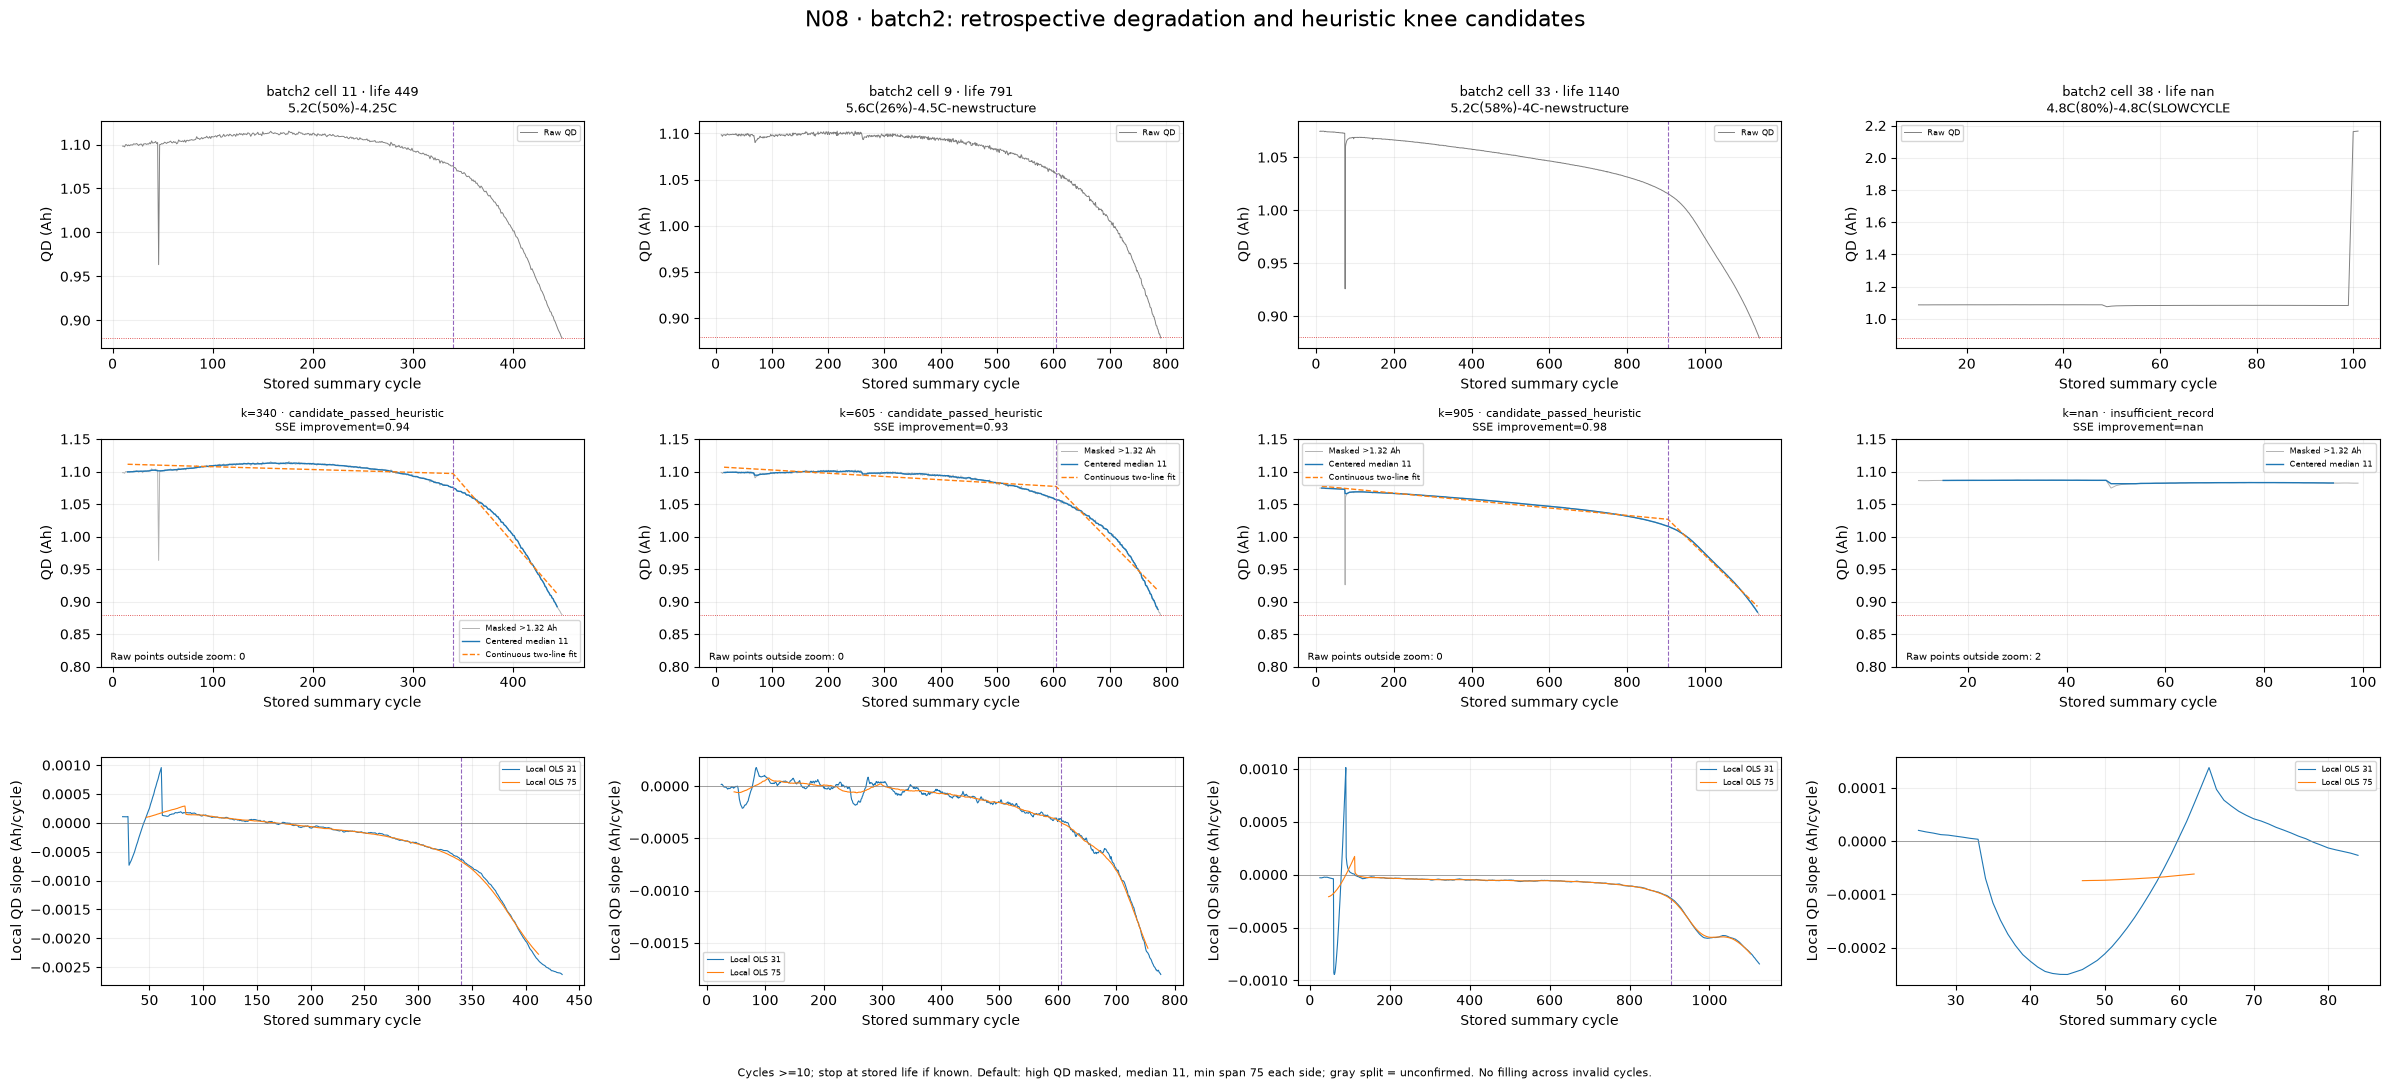

In [7]:
fig=wk.figure_knee_curves(selected,fits,'batch2')
fig.savefig(OUTPUT_DIR/'N08_batch2_degradation_knee.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

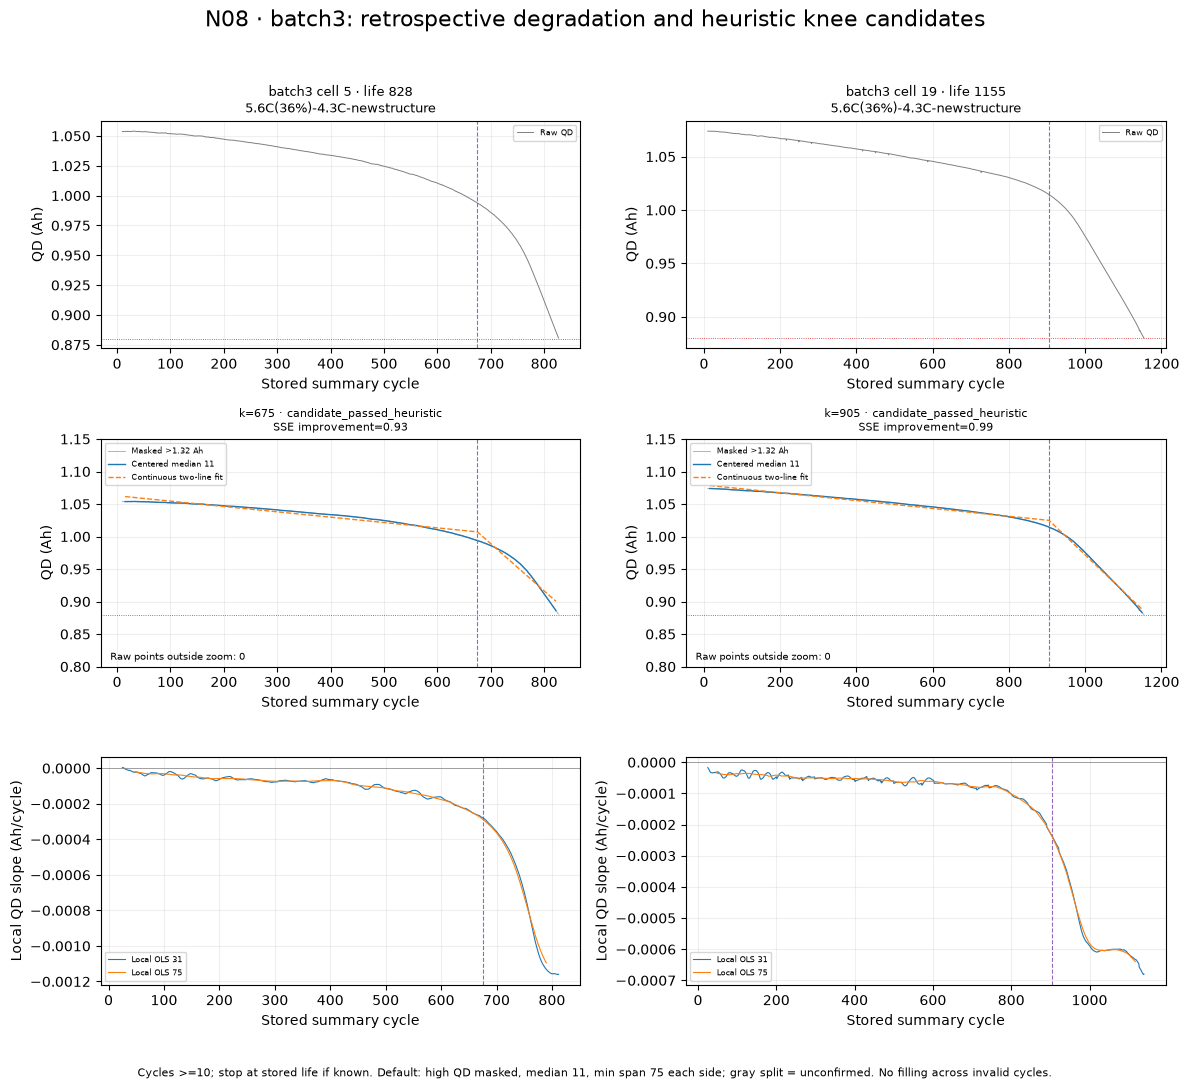

In [8]:
fig=wk.figure_knee_curves(selected,fits,'batch3')
fig.savefig(OUTPUT_DIR/'N08_batch3_degradation_knee.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

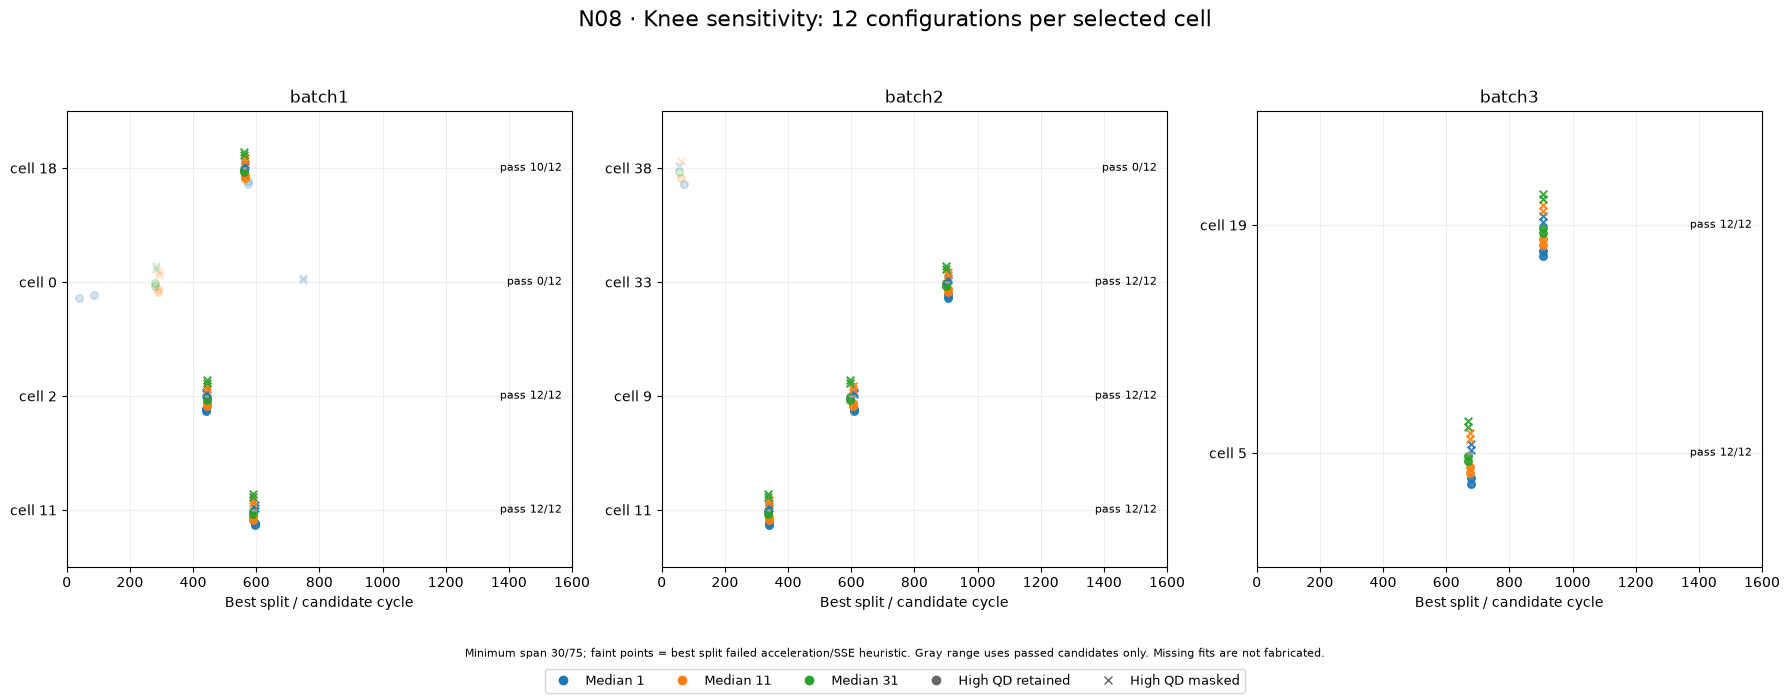

,batch,cell_id,mask_high_QD,median_window,min_span,cycle_life,n_fit,segment_start,segment_end,candidate_cycle,pre_slope,post_slope,relative_sse_improvement,fit_a,fit_b,fit_c,status
9,batch1,11,True,11,75,788.0,768,15.0,782.0,590.0,-0.000063,-0.000704,0.971929,1.066641,-0.000063,-0.000641,candidate_passed_heuristic
21,batch1,2,True,11,75,1177.0,1157,15.0,1171.0,445.0,-0.000024,-0.000045,0.848279,1.086813,-0.000024,-0.000021,candidate_passed_heuristic
33,batch1,0,True,11,75,1190.0,1167,18.0,1184.0,293.0,-0.000033,-0.000045,0.091169,1.077880,-0.000033,-0.000012,best_split_unconfirmed
45,batch1,18,True,11,75,691.0,640,46.0,685.0,566.0,-0.000128,-0.000974,0.976373,1.071804,-0.000128,-0.000846,candidate_passed_heuristic
57,batch2,11,True,11,75,449.0,430,15.0,444.0,340.0,-0.000044,-0.001776,0.939422,1.111132,-0.000044,-0.001732,candidate_passed_heuristic
69,batch2,9,True,11,75,791.0,772,15.0,786.0,605.0,-0.000050,-0.000884,0.927967,1.106612,-0.000050,-0.000833,candidate_passed_heuristic
81,batch2,33,True,11,75,1140.0,1121,15.0,1135.0,905.0,-0.000057,-0.000582,0.982030,1.077398,-0.000057,-0.000525,candidate_passed_heuristic
93,batch2,38,True,11,75,NaN,80,15.0,94.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,insufficient_record
105,batch3,5,True,11,75,828.0,808,15.0,822.0,675.0,-0.000082,-0.000726,0.930565,1.061466,-0.000082,-0.000644,candidate_passed_heuristic
117,batch3,19,True,11,75,1155.0,1135,15.0,1149.0,905.0,-0.000060,-0.000560,0.985778,1.078481,-0.000060,-0.000500,candidate_passed_heuristic


In [9]:
fig=wk.figure_knee_sensitivity(fits)
fig.savefig(OUTPUT_DIR/'N08_knee_configuration_sensitivity.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)
display(fits[fits.mask_high_QD & fits.median_window.eq(11) & fits.min_span.eq(75)])

## 관찰 문서

[구간 비교·knee 관찰 보고서](../outputs/reports/day1/window_knee_observation_report.md)에 이미지와 실행 수치를 기록한다. 가장 높은 상관 또는 특정 knee 위치를 골라 모델 결과로 주장하지 않는다.